In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hesh97/titanicdataset-traincsv")

print("Path to dataset files:", path)

100%|██████████| 22.0k/22.0k [00:00<00:00, 852kB/s]

Extracting files...
Path to dataset files: C:\Users\Administrator\.cache\kagglehub\datasets\hesh97\titanicdataset-traincsv\versions\1


In [21]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier

In [12]:
data = pd.read_csv(os.path.join(path, os.listdir(path)[0]))
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [46]:
titanic_df = data.loc[:, ["Pclass", "Sex", "Age", "Fare", "Survived"]]
titanic_df = pd.get_dummies(titanic_df, drop_first=True)
titanic_df["Survived"] = titanic_df["Survived"].astype(int)
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].mean(), inplace=True)
titanic_df.isna().sum()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10864\4167833485.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].mean(), inplace=True)


Pclass      0
Age         0
Fare        0
Survived    0
Sex_male    0
dtype: int64

In [47]:

X = titanic_df.drop("Survived", axis=1).values
y = titanic_df["Survived"]

scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

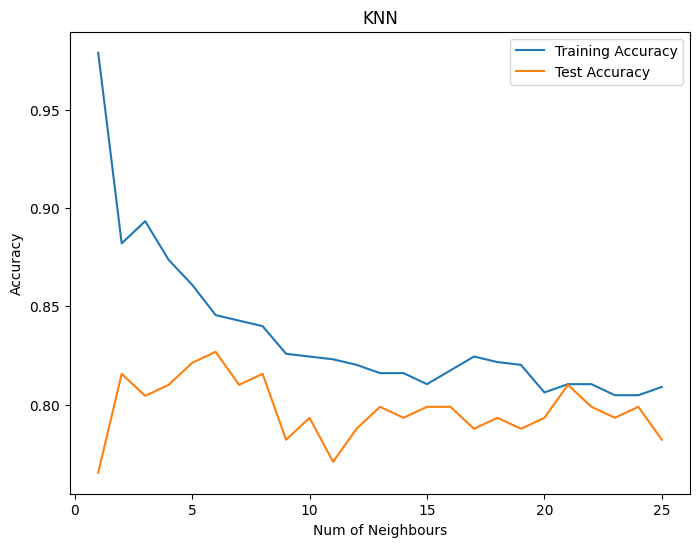

In [51]:
train_accuracies = {}
test_accuracies = {}
neighbours = np.arange(1, 26)

for n in neighbours:
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train_scaled, y_train)
    train_accuracies[n] = knn.score(X_train_scaled, y_train)
    test_accuracies[n] = knn.score(X_test_scaled, y_test)

plt.figure(figsize=[8,6])
plt.title("KNN")
plt.plot(neighbours, train_accuracies.values(), label="Training Accuracy")
plt.plot(neighbours, test_accuracies.values(), label="Test Accuracy")
plt.legend()
plt.xlabel("Num of Neighbours")
plt.ylabel("Accuracy")
plt.show()